<a href="https://colab.research.google.com/github/ShahMohammedSeaman/AirShootGame/blob/main/projects/Neuroscience/algonauts_videos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load algonauts videos

**By Neuromatch Academy**

__Content creators:__ Kshitij Dwivedi

__Produtction editors:__ Spiros Chavlis

---
# Terms of Use
By using this colab to download the brain dataset (i.e., data including fMRI, images, labels), you agree to the following terms:

1. You will use the Datasets only for non-commercial research and educational purposes.
2. You will NOT distribute the Datasets or any parts thereof.
3. Massachusetts Institute of Technology make no representations or warranties regarding the datasets, including but not limited to warranties of non-infringement or fitness for a particular purpose.
4. You accept full responsibility for your use of the datasets and shall defend and indemnify Massachusetts Institute of Technology and International Business Machines Corporation, including its employees, officers and agents, against any and all claims arising from your use of the datasets, including but not limited to your use of any copyrighted images that you may create from the datasets.
5. You will treat people appearing in this data with respect and dignity.
6. This data comes with no warranty or guarantee of any kind, and you accept full liability.

# Algonauts2021 dataset


Here we will load fMRI responses (whole brain + 9 ROIs) to 1000 video clips of 3 seconds and visualize in glass brain using nilearn.

**P.S.** The dataset provided is part of Algonauts 2021 Challenge. Please check the details [here](http://algonauts.csail.mit.edu/challenge.html) if you are interested in participating.

In [4]:
# @title Install dependencies
!pip install nilearn --quiet
!pip install decord --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 89.5 MB/s eta 0:00:00


In [5]:
# Imports
import os
import glob
import pickle

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

from nilearn import datasets
from nilearn import plotting

fsaverage = datasets.fetch_surf_fsaverage()

During previous years, each user had to use this [google form](https://forms.gle/qq9uqqu6SwN8ytxQ9) in order to receive the dropbox link with the corresponding dataset.

For this year you can use [this link](https://www.dropbox.com/s/agxyxntrbwko7t1/participants_data.zip1).

**Important:** You MUST set `dropbox_link` parameter `dl=1`, e.g., `https://www.dropbox.com/s/myurl/participants_data.zip?dl=1`



In [6]:
# @title Enter the dropbox link
dropbox_link = 'https://www.dropbox.com/s/agxyxntrbwko7t1/participants_data.zip?dl=1'

In [7]:
# @title Run the cell
import requests, zipfile, io

# Use the dropbox link to download the data
print(f"Dropbox link: {dropbox_link}")

if dropbox_link:
  fname1 = 'participants_data_v2021'
  fname2 = 'AlgonautsVideos268_All_30fpsmax'
  if not os.path.exists(fname1) or not os.path.exists(fname2):
    print('Data downloading...')
    r = requests.get(dropbox_link)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall()
    print('Data download is completed.')
  else:
    print('Data are already downloaded.')


  url = 'https://github.com/Neural-Dynamics-of-Visual-Cognition-FUB/Algonauts2021_devkit/raw/main/example.nii'
  fname = 'example.nii'
  if not os.path.exists(fname):
    r = requests.get(url, allow_redirects=True)
    with open(fname, 'wb') as fh:
      fh.write(r.content)
  else:
    print(f"{fname} file is already downloaded.")

else:
  print('You need to submit the form and get the dropbox link')

Dropbox link: https://www.dropbox.com/s/agxyxntrbwko7t1/participants_data.zip?dl=1
Data downloading...
Data download is completed.


#fMRI Data

The Algonauts dataset provides human brain responses to a set of 1,102 3-s long video clips of everyday events. The brain responses are measured with functional magnetic resonance imaging (fMRI). fMRI is a widely used brain imaging technique with high spatial resolution that measures blood flow changes associated with neural responses.

The training set consists of 1,000 video clips and the associated brain responses. The brain responses are provided here in two tracks corresponding to two independent tracks in the Algonauts challenge.

In the first track, brain responses provided are from selected voxels across the whole brain showing reliable responses to videos. The figure below shows the reliability values of different voxels in the brain.


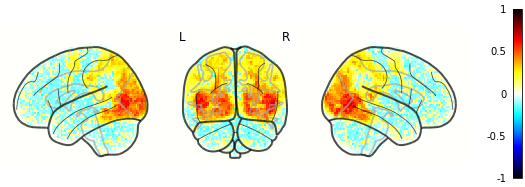

In the second track, brain responses provided are from a set of specific regions of interest (ROIs) known to play a key role in visual perception. These ROIs start in early and mid-level visual cortex (V1, V2, V3, and V4) and extend into higher-level cortex that responds preferentially to all objects or particular categories (Body- EBA; Face - FFA, STS; Object - LOC; Scene - PPA). In the figure below we show the masks of the above mentioned ROIs for an example subject.


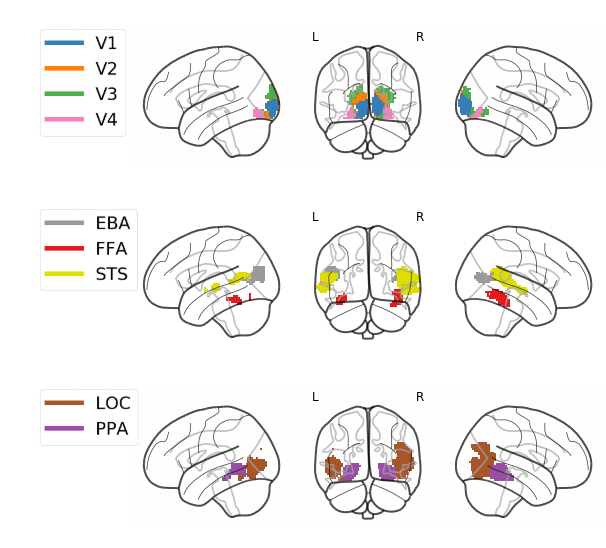

#Loading fMRI data
The dataset contains 1,000 3-second videos + fMRI human brain data of 10 subjects in response to viewing videos from this set.

The ROI data is provided for 9 ROIs of the visual brain (V1, V2, V3, V4, LOC, EBA, FFA, STS, PPA) in a Pickle file (e.g. V1.pkl) that contains a num_videos x num_repetitions x num_voxels matrix. For each ROI, we selected voxels that showed significant split-half reliability.

The whole brain data is provided for selected voxels across the whole brain showing reliable responses to videos in a Pickle file (e.g. WB.pkl) that contains a num_videos x num_repetitions x num_voxels matrix.

In this section, we demonstrate how to load fMRI data for a given ROI.

In [9]:
# @title Utility functions for data loading
def save_dict(di_, filename_):
  with open(filename_, 'wb') as f:
      pickle.dump(di_, f)

def load_dict(filename_):
  with open(filename_, 'rb') as f:
    u = pickle._Unpickler(f)
    u.encoding = 'latin1'
    ret_di = u.load()
    # print(p)
    # ret_di = pickle.load(f)
  return ret_di


def visualize_activity(vid_id,sub):
  # Setting up the paths for whole brain data
  fmri_dir = './participants_data_v2021'
  track = "full_track"

  # get the right track directory depending on whole brain/ROI choice
  track_dir = os.path.join(fmri_dir, track)

  # get the selected subject's directory
  sub_fmri_dir = os.path.join(track_dir, sub)

  #result directory to store nifti file
  results_dir = '/content/'

  # mapping the data to voxels and storing in a nifti file
  fmri_train_all,voxel_mask = get_fmri(sub_fmri_dir,"WB")
  visual_mask_3D = np.zeros((78,93,71))
  visual_mask_3D[voxel_mask==1]= fmri_train_all[vid_id,:]
  brain_mask = './example.nii'
  nii_save_path =  os.path.join(results_dir, 'vid_activity.nii')
  saveasnii(brain_mask,nii_save_path,visual_mask_3D)

  # visualizing saved nifti file
  plotting.plot_glass_brain(nii_save_path,
                          title='fMRI response',plot_abs=False,
                          display_mode='lyr',colorbar=True)


def get_fmri(fmri_dir, ROI):
  """This function loads fMRI data into a numpy array for to a given ROI.
  Parameters
  ----------
  fmri_dir : str
    path to fMRI data.
  ROI : str
    name of ROI.

  Returns
  -------
  np.array
    matrix of dimensions #train_vids x #repetitions x #voxels
    containing fMRI responses to train videos of a given ROI
  """

  # Loading ROI data
  ROI_file = os.path.join(fmri_dir, ROI + ".pkl")
  ROI_data = load_dict(ROI_file)
  # averaging ROI data across repetitions
  ROI_data_train = np.mean(ROI_data["train"], axis=1)
  if ROI == "WB":
    voxel_mask = ROI_data['voxel_mask']

    return ROI_data_train, voxel_mask

  return ROI_data_train

def saveasnii(brain_mask,nii_save_path,nii_data):
  img = nib.load(brain_mask)
  nii_img = nib.Nifti1Image(nii_data, img.affine, img.header)
  nib.save(nii_img, nii_save_path)

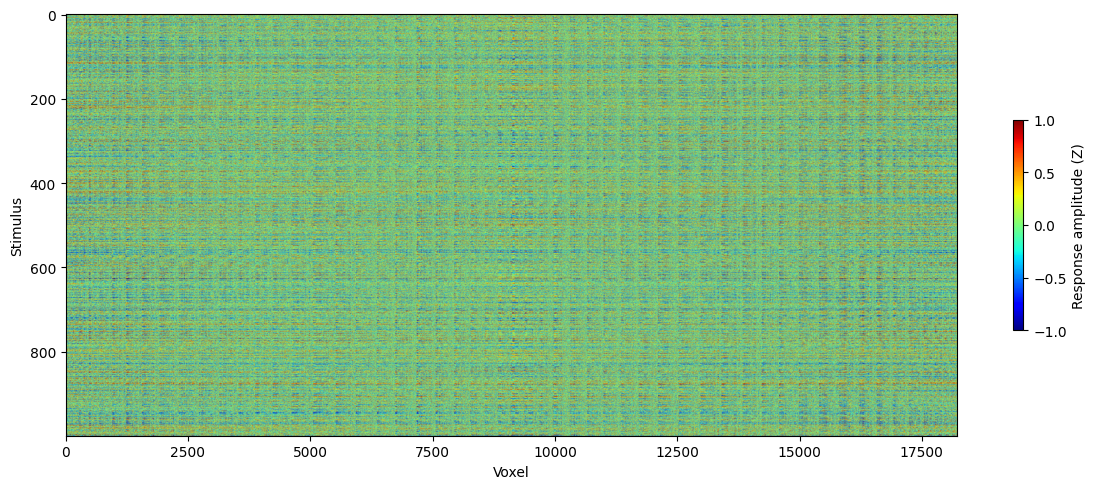

In [10]:
# @title Loading fMRI data and inspecting dimensions
# Select Subject
sub = 'sub01'  # @param ["sub01","sub02","sub03","sub04","sub05","sub06","sub07","sub08","sub09","sub10"]

# Select ROI
ROI = 'WB'  # @param ["WB", "V1", "V2","V3", "V4", "LOC", "EBA", "FFA","STS", "PPA"]

######## fMRI data loader wrapper code ###################################
fmri_dir = './participants_data_v2021'
if ROI == "WB":  # Loading whole brain data
  track = "full_track"  # stored in full_track directory
else:  # Loading ROI data
  track = "mini_track" # stored in mini_track directory

# get the right track directory depending on whole brain/ROI choice
track_dir = os.path.join(fmri_dir, track)

# get the selected subject's directory
sub_fmri_dir = os.path.join(track_dir, sub)

# Load the fMRI data for the selected subject and ROI
if track == "full_track":
  fmri_train_all,_ = get_fmri(sub_fmri_dir, ROI)
else:
  fmri_train_all = get_fmri(sub_fmri_dir, ROI)

######## fMRI data loader wrapper code ###################################

# Visualize the fMRI responses in a heatmap
f, ax = plt.subplots(figsize=(12, 5))
ax.set(xlabel="Voxel", ylabel="Stimulus")
heatmap = ax.imshow(fmri_train_all, aspect="auto", cmap='jet', vmin=-1, vmax=1)
f.colorbar(heatmap, shrink=.5, label="Response amplitude (Z)")
f.tight_layout()

The above matrix shows each individual voxel's (columns) response to 1000 videos (rows). To find out more details about how the fMRI responses were preprocessed please click [here](http://algonauts.csail.mit.edu/brainmappingandanalysis.html).

Visualize a given video (with id from 0-999)) and its corresponding brain activity

In [11]:
# @title Visualize video
from IPython.display import HTML
from base64 import b64encode

vid_id = 1  # @param {type: "integer"}
video_dir = './AlgonautsVideos268_All_30fpsmax'

########### Video display code #################################################
video_list = glob.glob(video_dir + '/*.mp4')
video_list.sort()

mp4 = open(video_list[vid_id],'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
  <source src="%s" type="video/mp4">
</video>
""" % data_url)
########### Video display code #################################################

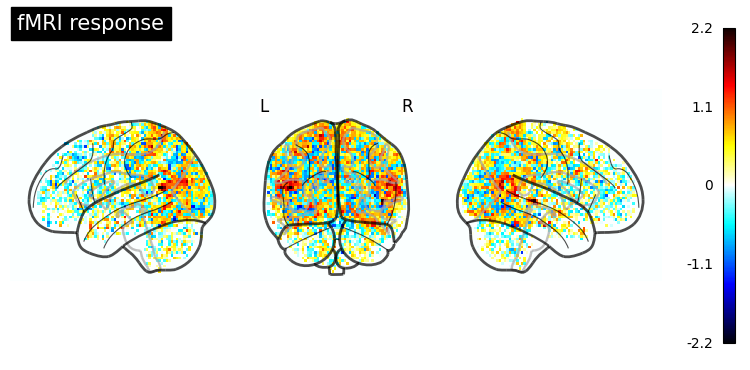

In [12]:
# @title Visualize corresponding brain response
visualize_activity(vid_id, sub)

The values in the fMRI response above correspond to beta values from 5s to 9s after stimulus onset calculated using an Finite Impulse Response (FIR) model. The beta values were averaged across time and z-scored across videos.

---
# References

1. Radoslaw Martin Cichy, Kshitij Dwivedi, Benjamin Lahner, Alex Lascelles, Polina Iamshchinina, Monika Graumann, Alex Andonian, Apurva Ratan Murty, Kendrick Kay, Gemma Roig, Aude Oliva. (2021). The Algonauts Project 2021 Challenge: How the Human Brain Makes Sense of a World in Motion. arXiv, [arXiv:2104.13714v1](https://arxiv.org/abs/2104.13714v1).

2. Radoslaw Martin Cichy, Gemma Roig, Alex Andonian, Kshitij Dwivedi, Benjamin Lahner, Alex Lascelles, Yalda Mohsenzadeh, Kandan Ramakrishnan, and Aude Oliva. (2019). The Algonauts Project: A Platform for Communication between the Sciences of Biological and Artificial Intelligence. arXiv, [arXiv:1905.05675](https://arxiv.org/abs/1905.05675).



In [56]:
import os
import cv2
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip

# Paths
video_path = "/content/AlgonautsVideos268_All_30fpsmax/0002_0-0-4-3146384004.mp4"  # 🔹 Input video
frame_dir = "./frames_combined"  # 🔹 Output frame storage
os.makedirs(frame_dir, exist_ok=True)

def extract_video_frames(video_path, output_dir):
    """ Extract frames from video and save as images. """
    cap = cv2.VideoCapture(video_path)
    success, frame_id = True, 0

    while success:
        success, frame = cap.read()
        if success:
            frame_path = os.path.join(output_dir, f"video_frame_{frame_id}.png")
            cv2.imwrite(frame_path, frame)
            frame_id += 1

    cap.release()
    print(f"✅ Extracted {frame_id} video frames.")

def visualize_activity(vid_id, sub):
    """ Generate fMRI response and save as image. """
    fmri_train_all, voxel_mask = get_fmri("./participants_data_v2021/full_track/" + sub, "WB")
    visual_mask_3D = np.zeros((78, 93, 71))
    visual_mask_3D[voxel_mask == 1] = fmri_train_all[vid_id, :]

    brain_mask = "./example.nii"
    nii_save_path = os.path.join(frame_dir, f"fmri_frame_{vid_id}.nii")
    saveasnii(brain_mask, nii_save_path, visual_mask_3D)

    # Generate MRI plot
    fig, ax = plt.subplots(figsize=(6, 6))
    plotting.plot_glass_brain(nii_save_path, title=f"fMRI Response",
                              plot_abs=False, display_mode="lyr", colorbar=False, axes=ax)

    # Save MRI frame
    fmri_path = os.path.join(frame_dir, f"fmri_frame_{vid_id}.png")
    plt.savefig(fmri_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    return fmri_path

def combine_frames(vid_id):
    """ Combine video frame and fMRI response into a single image. """
    vid_frame_path = os.path.join(frame_dir, f"video_frame_{vid_id}.png")
    fmri_frame_path = os.path.join(frame_dir, f"fmri_frame_{vid_id}.png")

    if not os.path.exists(vid_frame_path) or not os.path.exists(fmri_frame_path):
        return None  # Skip if missing

    vid_frame = cv2.imread(vid_frame_path)
    fmri_frame = cv2.imread(fmri_frame_path)

    # Resize fMRI frame to match width of video frame
    fmri_frame = cv2.resize(fmri_frame, (vid_frame.shape[1], int(vid_frame.shape[1] / fmri_frame.shape[1] * fmri_frame.shape[0])))

    # Stack video and fMRI response vertically
    combined_frame = np.vstack((vid_frame, fmri_frame))

    # Save final combined frame
    combined_path = os.path.join(frame_dir, f"combined_frame_{vid_id}.png")
    cv2.imwrite(combined_path, combined_frame)
    return combined_path

def create_video(output_path, fps=24):
    """ Convert frames into a final video. """
    # Edited to search for files that start with 'combined_frame_'
    # Previous pattern 'combined_frame2' would not match any files created in the for loop.
    frame_paths = sorted([os.path.join(frame_dir, f) for f in os.listdir(frame_dir) if f.startswith("combined_frame_")])

    # Check if frame_paths is empty before proceeding
    if not frame_paths:
        print("⚠️ No frames found to create video. Please check if frames were generated and saved correctly.")
        return

    clip = ImageSequenceClip(frame_paths, fps=fps)
    clip.write_videofile(output_path, codec="libx264")
    print(f"✅ Video saved at {output_path}")

# 🔹 Run the process
extract_video_frames(video_path, frame_dir)
for vid_id in range(20):
    fmri_path = visualize_activity(vid_id, "sub01")
    combine_frames(vid_id)

create_video("./output_combined5.mp4", fps=24)


✅ Extracted 91 video frames.
Moviepy - Building video ./output_combined5.mp4.
Moviepy - Writing video ./output_combined5.mp4



Moviepy - Done !
Moviepy - video ready ./output_combined5.mp4
✅ Video saved at ./output_combined5.mp4


In [1]:
!pip install torch torchvision transformers timm captum


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import ViTModel, CLIPProcessor, CLIPModel
from captum.attr import GuidedBackprop
import numpy as np

# ==============================
# 1️⃣ Video Feature Extraction with Vision Transformer (ViT)
# ==============================
class VideoFeatureExtractor(nn.Module):
    def __init__(self):
        super(VideoFeatureExtractor, self).__init__()
        self.vit = ViTModel.from_pretrained("facebook/dino-vitb16")

    def forward(self, video_frames):
        inputs = self.vit(pixel_values=video_frames).last_hidden_state
        return inputs.mean(dim=1)  # Aggregate frame features

# Instantiate Model
video_feature_extractor = VideoFeatureExtractor()

# ==============================
# 2️⃣ Contrastive Learning for Cross-Subject Generalization
# ==============================
def contrastive_loss(predicted, actual, temperature=0.1):
    similarity_matrix = F.cosine_similarity(predicted, actual, dim=-1)
    return -torch.log(torch.exp(similarity_matrix / temperature).sum())

# ==============================
# 3️⃣ CLIP-based Brain-Video Alignment
# ==============================
class CLIPFeatureExtractor(nn.Module):
    def __init__(self):
        super(CLIPFeatureExtractor, self).__init__()
        self.clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    def forward(self, video_frame):
        inputs = self.processor(images=video_frame, return_tensors="pt")
        features = self.clip_model.get_image_features(**inputs)
        return features

# Instantiate Model
clip_feature_extractor = CLIPFeatureExtractor()

# ==============================
# 4️⃣ Saliency Mapping with Grad-CAM
# ==============================
def compute_saliency_map(model, input_video):
    gbp = GuidedBackprop(model)
    saliency = gbp.attribute(input_video, target=0)
    return saliency

# ==============================
# 5️⃣ Future Brain State Prediction using LSTM
# ==============================
class BrainStatePredictor(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(BrainStatePredictor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        x, _ = self.lstm(x)
        return self.fc(x)

# Instantiate Model
brain_predictor = BrainStatePredictor(input_size=512, hidden_size=256)

# ==============================
# 🛠 Sample Data Simulation
# ==============================
# Simulate random video input tensor (Batch x Frames x Channels x Height x Width)
video_input = torch.rand(2, 3, 224, 224)  # (Batch=2, Channels=3, Height=224, Width=224)

# Simulate fMRI brain activity vectors (Batch x Features)
fmri_brain_activity = torch.rand(2, 512)  # Assuming 512 features

# ==============================
# 🎯 Running the Full Pipeline
# ==============================
print("🔍 Extracting Video Features using ViT...")
video_features = video_feature_extractor(video_input)

print("🔗 Aligning Video and Brain Features using CLIP...")
clip_features = clip_feature_extractor(video_input)

print("📊 Computing Contrastive Loss...")
loss = contrastive_loss(clip_features, fmri_brain_activity)
print(f"Contrastive Loss: {loss.item()}")

print("🧠 Predicting Future Brain Activity...")
future_brain_states = brain_predictor(fmri_brain_activity)
print(f"Future Brain Predictions Shape: {future_brain_states.shape}")

print("🎭 Computing Saliency Map...")
saliency_map = compute_saliency_map(video_feature_extractor, video_input)
print(f"Saliency Map Shape: {saliency_map.shape}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/343M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vitb16 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

...

🔍 Extracting Video Features using ViT...


It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.


🔗 Aligning Video and Brain Features using CLIP...
📊 Computing Contrastive Loss...
Contrastive Loss: -0.534110426902771
🧠 Predicting Future Brain Activity...
Future Brain Predictions Shape: torch.Size([2, 512])
🎭 Computing Saliency Map...


/usr/local/lib/python3.11/dist-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/captum/attr/_core/guided_backprop_deconvnet.py:64: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


Saliency Map Shape: torch.Size([2, 3, 224, 224])


In [20]:
import os
import glob
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, plotting
from transformers import ViTModel, ViTFeatureExtractor, CLIPProcessor, CLIPModel
from torch.utils.data import Dataset, DataLoader
import cv2

# Load fMRI dataset (Replace with your actual data path)
data_path = "/content/participants_data_v2021"
fmri_files = sorted(glob.glob(os.path.join(data_path, "/content/example.nii")))

# Load ViT and CLIP
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Define fMRI dataset class
import torchvision.transforms as transforms

# Assuming fMRIDataset and transform are defined in previous cells.
# If not, include their definitions here.
class fMRIDataset(Dataset):
    def __init__(self, fmri_files, transform=None):
        self.fmri_files = fmri_files
        self.transform = transform

    def __len__(self):
        return len(self.fmri_files)

    def __getitem__(self, idx):
        fmri_data = nib.load(self.fmri_files[idx]).get_fdata()  # Load fMRI scan

        # Get original shape and calculate the center slice index
        x_dim, y_dim, z_dim = fmri_data.shape[:3]
        mid_slice_x = x_dim // 2
        mid_slice_y = y_dim // 2
        mid_slice_z = z_dim // 2

        # Extract slices using the center slice index
        img1 = fmri_data[mid_slice_x, :, :]  # Axial
        img2 = fmri_data[:, mid_slice_y, :]  # Coronal
        img3 = fmri_data[:, :, mid_slice_z]  # Sagittal

        # Resize slices to the same dimensions before stacking
        img1 = cv2.resize(img1, (224, 224))  # Resize to ViT input size
        img2 = cv2.resize(img2, (224, 224))
        img3 = cv2.resize(img3, (224, 224))

        # Stack to create a 3-channel image
        img = np.stack([img1, img2, img3], axis=-1)
        img = (img - img.min()) / (img.max() - img.min())  # Normalize [0,1]

        # Check if transform is defined before applying
        if self.transform:
            img = self.transform(img)  # Apply transformations
        else:
            # Define a default transform if not provided
            transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor(),
            ])
            img = transform(img)
        return img

# Create dataloader
transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor(),
            ])
fmri_dataset = fMRIDataset(fmri_files, transform=transform) #Pass the transform
fmri_loader = DataLoader(fmri_dataset, batch_size=4, shuffle=True)

# Define contrastive learning loss
# ... (Rest of your code) ...

# Define contrastive learning loss
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = torch.nn.functional.pairwise_distance(output1, output2)
        loss = torch.mean((1 - label) * torch.pow(euclidean_distance, 2) +
                          label * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss

# Define training loop
contrastive_loss = ContrastiveLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=1e-4)

def train_model():
    vit_model.train()
    for epoch in range(10):  # Adjust epochs
        for batch in fmri_loader:
            optimizer.zero_grad()
            outputs = vit_model(batch).last_hidden_state
            loss = contrastive_loss(outputs[:, 0, :], outputs[:, 1, :], torch.ones(batch.size(0)))
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}: Loss = {loss.item()}")

# Train model
train_model()


Epoch 1: Loss = 0.0
Epoch 2: Loss = 0.0
Epoch 3: Loss = 0.0
Epoch 4: Loss = 0.0
Epoch 5: Loss = 0.0
Epoch 6: Loss = 0.0
Epoch 7: Loss = 0.0
Epoch 8: Loss = 0.0
Epoch 9: Loss = 0.0
Epoch 10: Loss = 0.0


In [19]:
import os
import glob
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, plotting
from transformers import ViTModel, ViTFeatureExtractor, CLIPProcessor, CLIPModel
from torch.utils.data import Dataset, DataLoader

# Load fMRI dataset (Replace with your actual data path)
data_path = "/content/participants_data_v2021"
fmri_files = sorted(glob.glob(os.path.join(data_path, "/content/example.nii")))

# Load ViT and CLIP
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Define fMRI dataset class
import torchvision.transforms as transforms

class fMRIDataset(Dataset):
    # ... (other methods) ...

    def __getitem__(self, idx):
        fmri_data = nib.load(self.fmri_files[idx]).get_fdata()  # Load fMRI scan

        # Get original shape and calculate the center slice index
        x_dim, y_dim, z_dim = fmri_data.shape[:3]
        mid_slice_x = x_dim // 2
        mid_slice_y = y_dim // 2
        mid_slice_z = z_dim // 2

        # Extract slices using the center slice index
        img1 = fmri_data[mid_slice_x, :, :]  # Axial
        img2 = fmri_data[:, mid_slice_y, :]  # Coronal
        img3 = fmri_data[:, :, mid_slice_z]  # Sagittal

        # Resize slices to the same dimensions before stacking
        img1 = cv2.resize(img1, (224, 224))  # Resize to ViT input size
        img2 = cv2.resize(img2, (224, 224))
        img3 = cv2.resize(img3, (224, 224))

        # Stack to create a 3-channel image
        img = np.stack([img1, img2, img3], axis=-1)
        img = (img - img.min()) / (img.max() - img.min())  # Normalize [0,1]
        img = transform(img)  # Apply transformations

        return img

# Create dataloader
fmri_dataset = fMRIDataset(fmri_files)
fmri_loader = DataLoader(fmri_dataset, batch_size=4, shuffle=True)

# Define contrastive learning loss
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = torch.nn.functional.pairwise_distance(output1, output2)
        loss = torch.mean((1 - label) * torch.pow(euclidean_distance, 2) +
                          label * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss

# Define training loop
contrastive_loss = ContrastiveLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=1e-4)

def train_model():
    vit_model.train()
    for epoch in range(10):  # Adjust epochs
        for batch in fmri_loader:
            optimizer.zero_grad()
            outputs = vit_model(batch).last_hidden_state
            loss = contrastive_loss(outputs[:, 0, :], outputs[:, 1, :], torch.ones(batch.size(0)))
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}: Loss = {loss.item()}")

# Train model
train_model()

TypeError: fMRIDataset() takes no arguments

In [15]:
print("Number of fMRI files found:", len(fmri_files))
print("Sample file:", fmri_files[:3])  # Print a few file paths


Number of fMRI files found: 0
Sample file: []


In [23]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import nibabel as nib
from transformers import ViTModel, ViTFeatureExtractor
from torch.utils.data import Dataset, DataLoader
import cv2

# Load fMRI dataset
DATA_PATH = "/content/participants_data_v2021"
FMRI_FILES = sorted(glob.glob(os.path.join(DATA_PATH, "/content/participants_data_v2021/full_track/sub01/WB.pkl")))  # Correct file pattern

# Load ViT model and feature extractor
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")

# Define fMRI dataset class
class fMRIDataset(Dataset):
    def __init__(self, fmri_files, transform=None):
        self.fmri_files = fmri_files
        self.transform = transform

    def __len__(self):
        return len(self.fmri_files)

    def __getitem__(self, idx):
        fmri_data = nib.load(self.fmri_files[idx]).get_fdata()
        x_dim, y_dim, z_dim = fmri_data.shape[:3]

        # Extract central slices
        img1 = fmri_data[x_dim // 2, :, :]
        img2 = fmri_data[:, y_dim // 2, :]
        img3 = fmri_data[:, :, z_dim // 2]

        # Resize slices to 224x224
        img1 = cv2.resize(img1, (224, 224))
        img2 = cv2.resize(img2, (224, 224))
        img3 = cv2.resize(img3, (224, 224))

        # Normalize and stack
        img = np.stack([img1, img2, img3], axis=-1)
        img = (img - np.min(img)) / (np.max(img) - np.min(img))

        # Convert to tensor
        if self.transform:
            img = self.transform(img)
        else:
            transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor()
            ])
            img = transform(img)

        return img

# Create dataloader
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])
fmri_dataset = fMRIDataset(FMRI_FILES, transform=transform)
fmri_loader = DataLoader(fmri_dataset, batch_size=4, shuffle=True)

# Define Contrastive Loss
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = torch.nn.functional.pairwise_distance(output1, output2)
        loss = torch.mean((1 - label) * torch.pow(euclidean_distance, 2) +
                          label * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss

# Initialize loss and optimizer
contrastive_loss = ContrastiveLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=5e-5)  # Lower learning rate

# Training function
def train_model(epochs=10):
    vit_model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batch in fmri_loader:
            batch = batch.to(torch.float32)  # Ensure correct dtype
            optimizer.zero_grad()

            outputs = vit_model(batch).last_hidden_state
            loss = contrastive_loss(outputs[:, 0, :], outputs[:, 1, :], torch.ones(batch.size(0)))
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(fmri_loader)}")

# Train model
train_model()


ImageFileError: Cannot work out file type of "/content/participants_data_v2021/full_track/sub01/WB.pkl"

In [39]:
import os
import glob
import pickle
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset
from transformers import ViTModel, ViTFeatureExtractor
from nilearn import plotting

# ---------------------- Helper Functions ----------------------

def save_dict(di_, filename_):
    """Save a dictionary using pickle."""
    with open(filename_, 'wb') as f:
        pickle.dump(di_, f)

def load_dict(filename_):
    """Load a dictionary using pickle (handling potential encoding issues)."""
    with open(filename_, 'rb') as f:
        u = pickle._Unpickler(f)
        u.encoding = 'latin1'  # Fix encoding issue for Python 3
        return u.load()

def saveasnii(brain_mask, nii_save_path, nii_data):
    """Save NIfTI image using an existing brain mask."""
    try:
        img = nib.load(brain_mask)
        nii_img = nib.Nifti1Image(nii_data, img.affine, img.header)
        nib.save(nii_img, nii_save_path)
    except Exception as e:
        print(f"Error saving NIfTI file: {e}")

# ---------------------- fMRI Data Handling ----------------------

def get_fmri(fmri_dir, ROI):
    """Load fMRI data and return voxel responses and masks."""
    ROI_file = os.path.join(fmri_dir, ROI + ".pkl")

    if not os.path.exists(ROI_file):
        raise FileNotFoundError(f"ROI file not found: {ROI_file}")

    ROI_data = load_dict(ROI_file)

    # Ensure 'train' key exists
    if "train" not in ROI_data:
        raise KeyError(f"'train' key missing in ROI data: {ROI_file}")

    # Average across repetitions
    ROI_data_train = np.mean(ROI_data["train"], axis=1)

    if ROI == "WB":
        if "voxel_mask" not in ROI_data:
            raise KeyError(f"'voxel_mask' key missing in ROI data: {ROI_file}")
        return ROI_data_train, ROI_data['voxel_mask']

    return ROI_data_train

# ---------------------- Visualization ----------------------

def visualize_activity(vid_id, sub):
    """Visualize fMRI activity for a given video and subject."""
    fmri_dir = "./participants_data_v2021"
    track = "full_track"
    sub_fmri_dir = os.path.join(fmri_dir, track, sub)

    if not os.path.exists(sub_fmri_dir):
        raise FileNotFoundError(f"Subject fMRI directory not found: {sub_fmri_dir}")

    results_dir = "./"
    fmri_train_all, voxel_mask = get_fmri(sub_fmri_dir, "WB")

    visual_mask_3D = np.zeros((78, 93, 71))  # Adjusted for known fMRI shape
    visual_mask_3D[voxel_mask == 1] = fmri_train_all[vid_id, :]

    brain_mask = "./example.nii"
    nii_save_path = os.path.join(results_dir, "vid_activity.nii")
    saveasnii(brain_mask, nii_save_path, visual_mask_3D)

    plotting.plot_glass_brain(
        nii_save_path, title="fMRI response", plot_abs=False,
        display_mode="lyr", colorbar=True
    )

# ---------------------- fMRI Dataset Class ----------------------

class fMRIDataset(Dataset):
    def __init__(self, fmri_files, transform=None):
        self.fmri_files = fmri_files
        self.transform = transform

        if not self.fmri_files:
            raise ValueError("No fMRI files found!")

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.fmri_files)  # This line is added to fix the error

    def __getitem__(self, idx):
      with open(self.fmri_files[idx], 'rb') as f:
        fmri_data = pickle.load(f)

      if isinstance(fmri_data, dict) and "train" in fmri_data:
        print(f"Original fMRI data shape: {fmri_data['train'].shape}")  # Debug

        # Step 1: Average across trials (axis 0) → Shape (3, 18222)
        fmri_data = np.mean(fmri_data["train"], axis=0)

        # Step 2: Average across repetitions (axis 0) → Shape (18222,)
        fmri_data = np.mean(fmri_data, axis=0)

    # Convert to PyTorch tensor
      fmri_tensor = torch.tensor(fmri_data, dtype=torch.float32)

      print(f"Final tensor shape: {fmri_tensor.shape}")  # Debug
      return fmri_tensor







# ---------------------- Load Dataset & ViT Model ----------------------

DATA_PATH = "/content/participants_data_v2021"
fmri_dir = os.path.join(DATA_PATH, "full_track", "sub01")

# Check for existing fMRI files
FMRI_FILES = [os.path.join(fmri_dir, "WB.pkl")]
if not os.path.exists(FMRI_FILES[0]):
    raise FileNotFoundError("No fMRI files found. Check your file paths!")

# Load Vision Transformer (ViT) Model
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")

# Create fMRI dataset
fmri_dataset = fMRIDataset(FMRI_FILES)

# Example Usage
print(f"Dataset size: {len(fmri_dataset)}")
sample = fmri_dataset[0]
print(f"Sample fMRI data shape: {sample.shape}")


Dataset size: 1
Original fMRI data shape: (1000, 3, 18222)
Final tensor shape: torch.Size([18222])
Sample fMRI data shape: torch.Size([18222])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

# Step 1: Normalize fMRI Data
def normalize_fmri(fmri_data):
    mean = fmri_data.mean(dim=-1, keepdim=True)
    std = fmri_data.std(dim=-1, keepdim=True) + 1e-5  # Avoid division by zero
    return (fmri_data - mean) / std

# Example fMRI data (T, C, V) -> (1000, 3, 18222)
fmri_data = torch.rand(1000, 3, 18222)  # Simulated data
normalized_fmri = normalize_fmri(fmri_data)

print(f"Original Shape: {fmri_data.shape}")
print(f"Normalized Shape: {normalized_fmri.shape}")

# Step 2: Pad & Reshape to Pseudo-Image
def reshape_fmri_to_image(fmri_data, target_size=(224, 224)):
    """
    1. Pads last dimension from 18222 to 18224 (so it's divisible by 134×136)
    2. Reshapes it into a 2D (H, W) format
    3. Resizes it to (224, 224) for ViT
    """
    H, W = 134, 136  # Closest to 18222 features
    pad_size = (0, 2)  # Pad last dim to 18224
    fmri_padded = F.pad(fmri_data, pad_size, mode='constant', value=0)

    fmri_image = fmri_padded.view(fmri_data.shape[0], 3, H, W)  # (N, C, H, W)
    fmri_resized = F.interpolate(fmri_image, size=target_size, mode="bilinear")

    return fmri_resized

fmri_pseudo_image = reshape_fmri_to_image(normalized_fmri)

print(f"Reshaped fMRI Pseudo-Image Shape: {fmri_pseudo_image.shape}")

# Step 3: Define a ViT Model
class ViTFeatureExtractor(nn.Module):
    def __init__(self):
        super(ViTFeatureExtractor, self).__init__()
        self.vit = models.vit_b_16(pretrained=True)
        self.vit.heads = nn.Identity()  # Remove classification layer

    def forward(self, x):
        return self.vit(x)

# Initialize Model
vit_extractor = ViTFeatureExtractor()

# Step 4: Extract Features
fmri_embeddings = vit_extractor(fmri_pseudo_image)

print(f"Extracted ViT Features Shape: {fmri_embeddings.shape}")


Original Shape: torch.Size([1000, 3, 18222])
Normalized Shape: torch.Size([1000, 3, 18222])
Reshaped fMRI Pseudo-Image Shape: torch.Size([1000, 3, 224, 224])


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
